In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_dir = "/content/drive/MyDrive/Plant_disease"


In [4]:
class_names = os.listdir(dataset_dir)

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite']


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [7]:
class_names = train_ds.class_names

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [8]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape:", images.shape)
    print("Label Batch Shape:", labels.shape)

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32,)


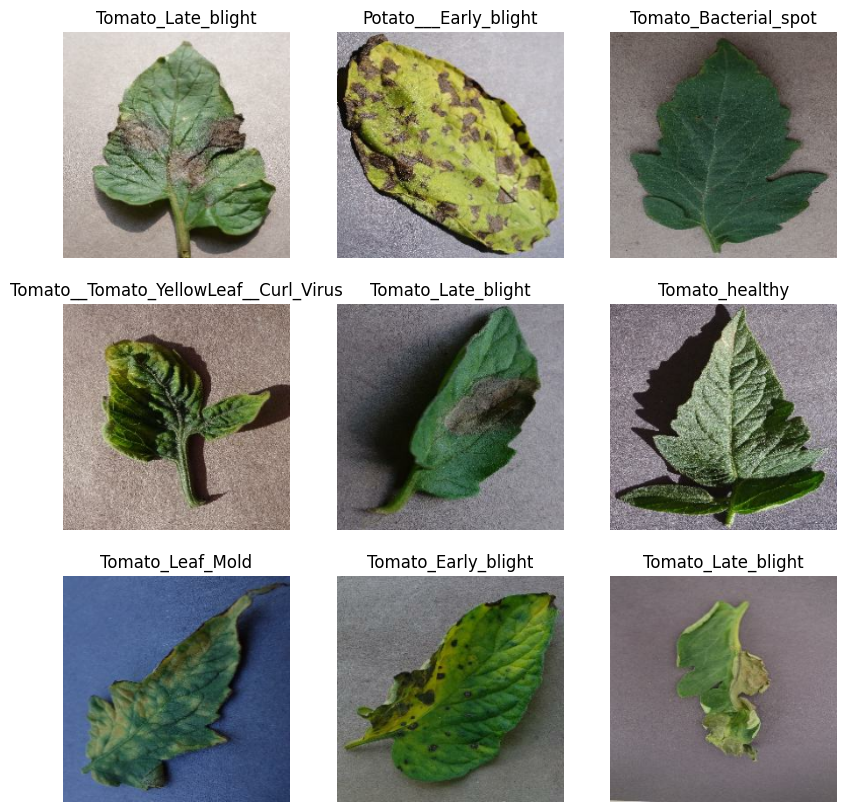

In [9]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [11]:
from tensorflow.keras import models, layers

model = models.Sequential([

    # Input Layer
    layers.Input(shape=(224, 224, 3)),

    # First Convolution Block
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Second Convolution Block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Third Convolution Block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(len(class_names), activation='softmax')
])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1382s 3s/step - accuracy: 0.6499 - loss: 1.0763 - val_accuracy: 0.7933 - val_loss: 0.6476
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 74s 143ms/step - accuracy: 0.7318 - loss: 0.7931 - val_accuracy: 0.7902 - val_loss: 0.6454
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 75s 145ms/step - accuracy: 0.7803 - loss: 0.6631 - val_accuracy: 0.8551 - val_loss: 0.4352
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 75s 146ms/step - accuracy: 0.8175 - loss: 0.5349 - val_accuracy: 0.8730 - val_loss: 0.3852
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 76s 148ms/step - accuracy: 0.8465 - loss: 0.4500 - val_accuracy: 0.8805 - val_loss: 0.3620
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 81s 158ms/step - accuracy: 0.8678 - loss: 0.3822 - val_accuracy: 0.9033 - val_loss: 0.2960
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 75s 146ms/step - accuracy: 0.8833 - loss: 0.3360 - val_accuracy: 0.8977 - val_loss: 0.3321
Epoch 8/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 77s 149ms/step - accuracy: 0.8939 - loss: 0.

In [16]:
test_loss, test_accuracy = model.evaluate(val_ds)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.9208 - loss: 0.4625
Validation Loss: 0.46245887875556946
Validation Accuracy: 0.9207656979560852


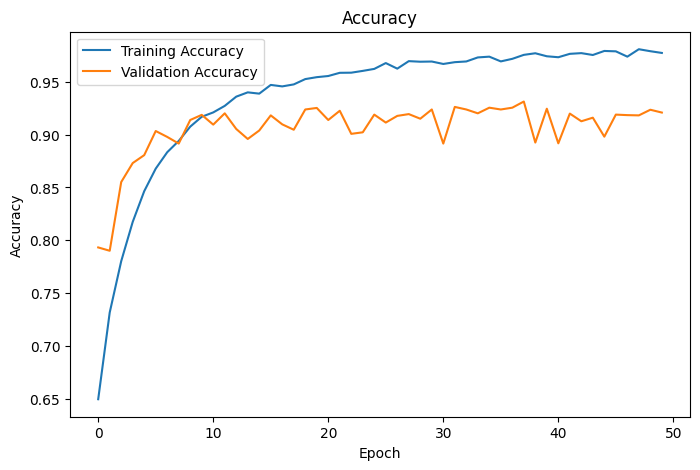

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.show()

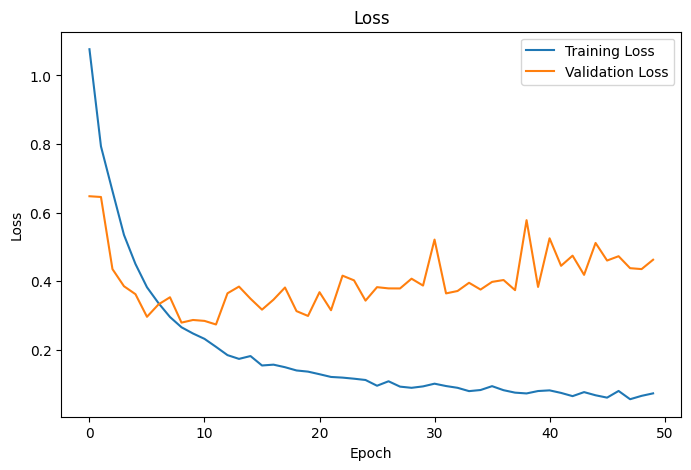

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [53]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/images (1).jfif"

img = image.load_img(img_path, target_size=(224,224))

In [54]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [55]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [56]:
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction[0])

print("Predicted Disease:", class_names[predicted_class])
print("Confidence:", prediction[0][predicted_class] * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Disease: Pepper__bell___Bacterial_spot
Confidence: 100.0


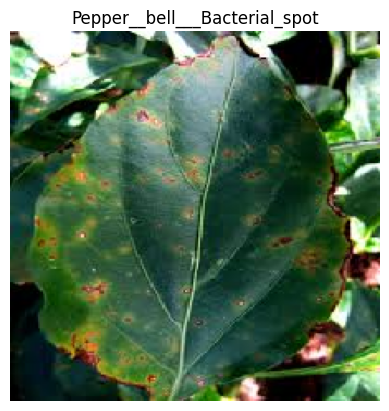

In [57]:
plt.imshow(img)
plt.title(class_names[predicted_class])
plt.axis("off")
plt.show()

In [58]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Training Accuracy: 0.9771061539649963
Validation Accuracy: 0.9207656979560852


In [59]:
model.save("plant_disease_model.keras")

print("Model saved successfully!")

Model saved successfully!
